## Installing Dependencies

In [ ]:
!pip install ucimlrepo

## Importing ucimlrepo library

In [ ]:
from ucimlrepo import fetch_ucirepo

## Fetching datasets

In [ ]:
HD_main = fetch_ucirepo(id=45)
W_main = fetch_ucirepo(id=109)

In [ ]:
hddf = HD_main.data.original
wdf = W_main.data.original

In [ ]:
hddf

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


In [ ]:
wdf

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,3
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,3
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,3
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,3


## Cleaning dataset

In [ ]:
hddf = hddf.dropna()
wdf = wdf.dropna()

In [ ]:
hddf_target = hddf['num']
hddf_features = hddf.drop('num',axis=1)
wdf_target = wdf['class']
wdf_features = wdf.drop('class',axis=1)

## Importing libraries for model training

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score,precision_score

## Standardising features

In [ ]:
se = StandardScaler()
hddf_features = pd.DataFrame(se.fit_transform(hddf_features))
wdf_features = pd.DataFrame(se.fit_transform(wdf_features))

## Train test splitting data

In [ ]:
hddf_X_train, hddf_X_test, hddf_y_train, hddf_y_test = train_test_split(hddf_features, hddf_target, test_size=0.2)
wdf_X_train, wdf_X_test, wdf_y_train, wdf_y_test = train_test_split(wdf_features, wdf_target, test_size=0.2)

## Fitting model

In [ ]:
hddf_ada_model = AdaBoostClassifier()
wdf_ada_model = AdaBoostClassifier()

In [ ]:
hddf_ada_model.fit(hddf_X_train, hddf_y_train)
wdf_ada_model.fit(wdf_X_train, wdf_y_train)

AdaBoostClassifier()

In [ ]:
hddf_y_pred = hddf_ada_model.predict(hddf_X_test)
wdf_y_pred = wdf_ada_model.predict(wdf_X_test)


## Getting classification report

In [ ]:
hddf_report = pd.DataFrame(classification_report(hddf_y_test, hddf_y_pred,output_dict=True))
wdf_report = pd.DataFrame(classification_report(wdf_y_test, wdf_y_pred,output_dict=True))


In [ ]:
hddf_report

,0,1,2,3,4,accuracy,macro avg,weighted avg
precision,0.862069,0.285714,0.071429,0.500000,0.0,0.516667,0.343842,0.608580
recall,0.781250,0.307692,0.333333,0.100000,0.0,0.516667,0.304455,0.516667
f1-score,0.819672,0.296296,0.117647,0.166667,0.0,0.516667,0.280056,0.535016
support,32.000000,13.000000,3.000000,10.000000,2.0,0.516667,60.000000,60.000000


In [ ]:
wdf_report

,1,2,3,accuracy,macro avg,weighted avg
precision,1.0,1.000000,0.888889,0.972222,0.962963,0.975309
recall,1.0,0.947368,1.000000,0.972222,0.982456,0.972222
f1-score,1.0,0.972973,0.941176,0.972222,0.971383,0.972664
support,9.0,19.000000,8.000000,0.972222,36.000000,36.000000


## Showing calculated metrics

In [ ]:
print("Heart Disease Data Metrics:")
print(f"  Accuracy: {accuracy_score(hddf_y_test, hddf_y_pred)*100:.2f}%")
print(f"  Precision: {precision_score(hddf_y_test, hddf_y_pred, average='weighted', zero_division=0):.4f}")
print(f"  F1-Score: {f1_score(hddf_y_test, hddf_y_pred, average='weighted', zero_division=0):.4f}")
print("\nWine Data Metrics:")
print(f"  Accuracy: {accuracy_score(wdf_y_test, wdf_y_pred)*100:.2f}%")
print(f"  Precision: {precision_score(wdf_y_test, wdf_y_pred, average='weighted', zero_division=0):.4f}")
print(f"  F1-Score: {f1_score(wdf_y_test, wdf_y_pred, average='weighted', zero_division=0):.4f}")


Heart Disease Data Metrics:
  Accuracy: 51.67%
  Precision: 0.6086
  F1-Score: 0.5350

Wine Data Metrics:
  Accuracy: 97.22%
  Precision: 0.9753
  F1-Score: 0.9727


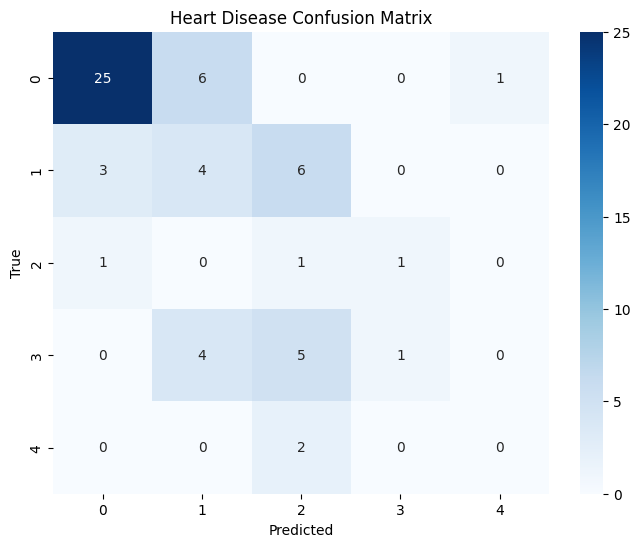

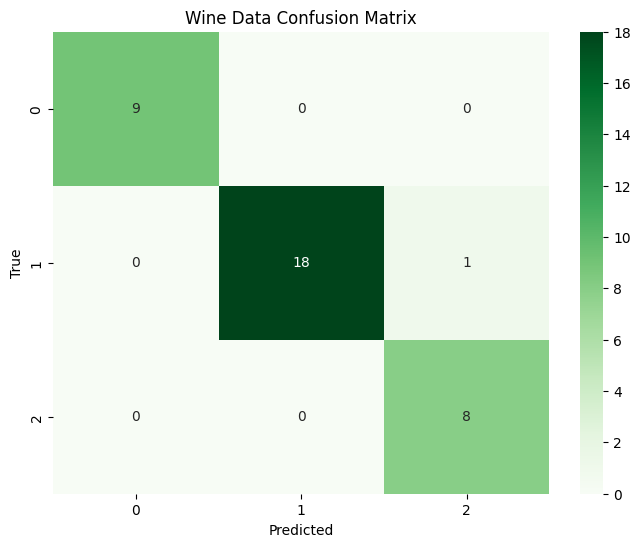

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

HD_cm = confusion_matrix(hddf_y_test, hddf_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(HD_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Heart Disease Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

W_cm = confusion_matrix(wdf_y_test, wdf_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(W_cm, annot=True, fmt='d', cmap='Greens')
plt.title('Wine Data Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()